In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Import dataset
dataset = pd.read_csv('mnist_test.csv', sep=',', header=None) 

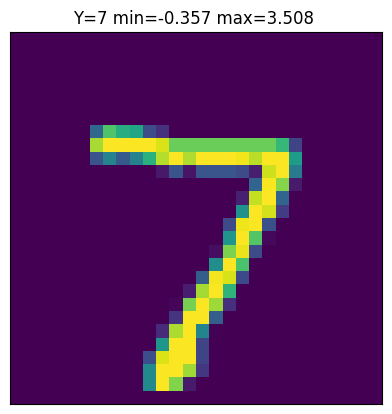

In [8]:
#I WANT PRECIDE THAT THIS NORMALIZATION IS NOT A NOMRALIZATION ADDAPT FOR A TRAINING STAGE BEECAUSE I COMPUTE THE MEANS NASS STANNDARD DERIVATION ON EACH INDIVUSDUAL IMAGE INSTEAD THE COMPUTE ONE GLOBALLY. HOWEVER FOR THE SEEK OF THE EXECRCISE I WILL USE THIS ONE.


D = []
#create Data
for row in dataset.values:
    #y.append(row[0])
    #X.append(row[1:])
    D.append([row[1:], row[0]]) # (features, target)



D = [[(x[0] - np.mean(x[0]))/np.std(x[0]), x[1]] for x in D]
#print("Attribute of the first object:", D[0][0], '\n')
D[0][1]




plt.matshow(np.reshape(D[0][0], [28,28]))

# smallest pixel, biggest pixel
y_label = D[0][1]
x_min = D[0][0].min() 
x_max = D[0][0].max()
plt.title(f"Y={y_label} min={x_min:.3f} max={x_max:.3f} ")
plt.xticks([])
plt.yticks([])
plt.show()





In [ ]:
#Remark even if the de question dow not specify tell me to split the dataset in traning set and test set and validation set i will do it anyway as i will need them for part B and C.
#I HAVE DECIDE TO SPLIT THE DATASET IN 23 PART. EVENTUALL Y I WILL CHANCKE THE CONFICUTION IF NEEDED.

#slip data in train val test
#SPLIT DATASET
np.random.seed(12345) 
reshuffle = np.random.choice(len(D),len(D), replace=False)
sizeData = int(len(D)/3) #took from lab

Dtrain = [D[i] for i in reshuffle[:sizeData]]
Dval = [D[i] for i in reshuffle[sizeData: 2*sizeData]]
Dtest = [D[i] for i in reshuffle[2*sizeData:]]

#test dimentions
#print(len(Dval)) #works
#print(f'|Dtrain|={len(Dtrain)},|Dval|={len(Dval)}, |Dtest|={len(Dtest)}')

#STANDARIDIZE DATA
Dtrain_X = np.array([d[0] for d in Dtrain])
Dval_V = np.array([d[0] for d in Dval])
Dtest_T = np.array([d[0] for d in Dtest])

mu = Dtrain_X.mean(axis=0) 
sigma = Dtrain_X.std(axis=0) + 1e-8 #took from lab. avoid division by zero.

Dtrain_X_norm = (Dtrain_X - mu)/sigma
Dval_V_norm = (Dval_V - mu)/sigma
Dtest_T_norm = (Dtest_T - mu)/sigma
#test normalization
#print(Dtrain_Xnorm[0])

In [ ]:
#This cell recombine the dataset normalize.
#Consider only two digits 8 and 2
# 8->1 and 2->0.    
# Pick two digit
eight_digit, two_digit = 8, 2
#print(f'Pick digits: {eight_digit} and {three_digit}')

#recombine all dataset that splitted previous section.
X_all = np.vstack([Dtrain_X_norm, Dval_V_norm, Dtest_T_norm])
y_all = np.concatenate([np.array([d[1] for d in Dtrain]),
                       np.array([v[1] for v in Dval]),
                       np.array([t[1] for t in Dtest])])


#print(f'X_all shape: {X_all.shape}, y_all shape: {y_all.shape}')
#select all eght and three
mask_ = (y_all == eight_digit) | (y_all == two_digit)
X_sel = X_all[mask_]
y_sel = (y_all[mask_] == eight_digit).astype(int) #force labet be 8->1 and 3->0
#print('y_sel:', y_sel)
N, d = X_sel.shape
#print(f'Number of selected samples: N={N}, d={d}')


In [ ]:
#Sigmoid function
#Simgmoid throught a warming but i have investigated. The numbers all in reasonable range.
def sigmoid(t):
    return 1.0 / (1.0 + np.exp(-t))
    

In [12]:
#Logistic Regession model
def LR(lam0, X):
    X_sel_with_bias = np.hstack([np.ones((X.shape[0],1)),X])
    return sigmoid(X_sel_with_bias @ lam0) # soigmoid give probability between 0 and 1

In [13]:

#Logistic Regression function
def GD(lam, X):
    X_sel_with_bias = np.hstack([np.ones((X.shape[0],1)),X])
    f = LR(lam,X)
    return (f*(1.0 - f))[:,None] * X_sel_with_bias


In [14]:
rnd = np.random.default_rng(123)
lam0 = rnd.normal(0, 1, size=d+1)
gd = GD(lam0, X_sel)
gd_norm = np.linalg.norm(gd, axis=1)
#print('gd shape:', gd.shape)
#print('gd morm shape:', gd_norm.shape)
#print('gd_Min():', gd.min(), ' gd_Max():', gd.max())



In [ ]:
#Make prediction 
f_val = LR(lam0, X_sel)
y_pred = (f_val >= 0.5).astype(int)
#print(y_pred)
err_rate = (y_pred != y_sel).mean()
#print('Error Rate:', err_rate)


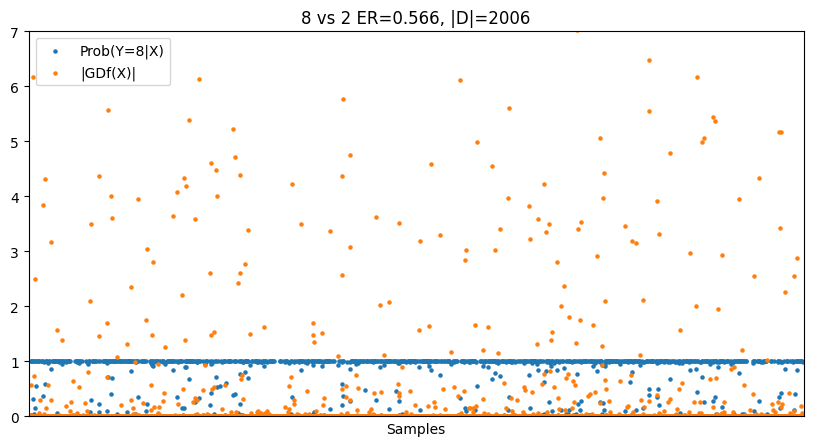

In [ ]:
#Plot graph
fig, ax = plt.subplots(figsize=(10,5))
plt.title(f'{eight_digit} vs {two_digit} ER={err_rate:.3f}, |D|={N}')
ax.scatter(np.arange(N), f_val, s=5, label="Prob(Y=8|X)")
ax.scatter(np.arange(N), gd_norm, s=5 ,label="|GDf(X)|")

#Dimension square
plt.ylim(0,7)
plt.xlim(0,N)
ax.set_xlabel("Samples")
ax.set_ylabel("")

ax.set_xticks([])
plt.legend()



In [ ]:
#Negative log-likehood fuction
#Added small regularization to avoid numerical issues.
def neg_log_lokelihood(lam, X, y,eps=1e-8):
    #print("eps in neg_log_lokelihood:", eps)
    f =  LR(lam, X)
    loss = - np.sum(y * np.log(f + eps)+(1-y) * np.log(1 - f + eps))
    return loss


In [ ]:
#Gradient of negative log-likehood
def grad_neg_log_likelihood(lam,X,y):
    f = LR(lam, X)
    X_sel_with_bias = np.hstack([np.ones((X.shape[0],1)),X])
    grad = X_sel_with_bias.T @ (f - y)
    return grad

In [ ]:
#Training stage
def train_logistic_GD(X_train, y_train, X_val, y_val, eta, T):
    d= X_train.shape[1]
    lam = np.zeros(d+1) #(d +1) for bias term
    
    train_loss = []
    val_loss = []

    
    for t in range(T):
        #compute the gradient inr espect paramenter
        #update paramter for the next iteration
        grad = grad_neg_log_likelihood(lam, X_train, y_train)
        lam -= eta * grad
        
        
        #compute the looses
        train_loss.append(neg_log_lokelihood(lam, X_train, y_train))
        val_loss.append(neg_log_lokelihood(lam, X_val, y_val))
    
    return lam, train_loss, val_loss 
    

In [20]:
Dtrain_Y = np.array([d[1] for d in Dtrain])
Dval_V_Y = np.array([d[1] for d in Dval])
Dtest_T_Y = np.array([d[1] for d in Dtest])

In [ ]:
#This function take two indiceces and convert 1 nad 0
def prepate_data(X, y, pos, neg,):
    mask =(y == pos) | (y == neg)
    X_ = X[mask]
    y_ = (y[mask] == pos).astype(int)
    return X_, y_

In [ ]:
#Transform data in 1, 0- for eight and two
eight_digit, two_digit = 8, 2
X_Tr, Y_Tr = prepate_data(Dtrain_X_norm, Dtrain_Y, eight_digit, two_digit)
#print('X_Tr shape:', X_Tr.shape)
#print('Y_Tr shape:', Y_Tr.shape)
X_V, Y_V = prepate_data(Dval_V_norm, Dval_V_Y, eight_digit, two_digit)
#print('X_V shape:', X_V.shape)
#print('Y_V shape:', Y_V.shape)
X_Te, Y_Te = prepate_data(Dtest_T_norm, Dtest_T_Y, eight_digit, two_digit)
#print('X_Te shape:', X_Te.shape)
#print('Y_Te shape:', Y_Te.shape)
    


In [ ]:
#This cell wants to find the best learning rate eta and best iteration T_best.
#IMPORTANT. I TRIED INVESITGATE ABOUT THE WARMINNG. FOR MY UNDERSTAND THIS WARMING CAUSED BY THE INCREASY OF DIMENTION IN -t(learning rate). BUT AFTER MAKE SOME TEST I CONCLUDED THAT IT DID NOT AFFECTED MY FUNAL RESULT. 
lowest_loss = float('inf')  # Initialize with very large number
best_eta = None
best_T = None
for i in [0.01,0.001,0.0001,0.00001]:
    eta = i
    #test
    #print('Learning rate eta:', eta)
    lam, train_loss, val_loss =train_logistic_GD(X_Tr, Y_Tr, X_V, Y_V, eta, T=500)
    #print(f"training loss: {train_loss[-1]} validation loss: {val_loss[-1]}")
    T_best = np.argmin(val_loss) #find best iteration
    current_best_val = val_loss[T_best]
    #print('vali loss',np.argmin(val_loss))
    #test
    #print('Best iteration T_best:', T_best, ' with val_loss:', current_best_val)

    if current_best_val < lowest_loss:
        lowest_loss = current_best_val
        best_eta = eta
        best_T = T_best
#test
#print('Best learning rate eta:', best_eta, ' with val_loss:', lowest_loss, ' at iteration T:', best_T)

C:\Users\papap\AppData\Local\Temp\ipykernel_21372\3981873084.py:4: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-t))


In [24]:
print('Best learning rate eta:', best_eta, ' with val_loss:', lowest_loss, ' at iteration T:', best_T)

Best learning rate eta: 0.0001  with val_loss: 59.19771338970436  at iteration T: 402


In [ ]:
#Re-train full dataset from the scratch.
#Save lambda every T_best/10 iterations.
def retrain_full_data_GD(X_all, y_all, eta, T_best):

    d = X_all.shape[1]
    lam = np.zeros(d + 1)  # restart from zero
    saved_lams = []
    all_loss = []

    #if Tbest is less thn 10 set save to 1
    #make sure that no devide by zero
    save_every = max(1, T_best // 10)  # avoid division by zero
    #test
    #print('The best T', T_best)
    #print('Save every', save_every, 'iterations')
    for t in range(T_best):
        # compute gradient and update
        grad = grad_neg_log_likelihood(lam, X_all, y_all)
        lam -= eta * grad
        
        # compute loss on full dataset
        loss = neg_log_lokelihood(lam, X_all, y_all)
        #print('loss',loss)
        all_loss.append(loss)

        # save model at checkpoints
        if t % save_every == 0 or t == T_best - 1:
            saved_lams.append(lam.copy())

    return lam, saved_lams, all_loss


In [ ]:
#This cell recombine the dataset normalize.
#Consider only two digits 8 and 2 
#8->1 and 2->0.
#Combine training and validation sets
X_Tran_and_Val = np.vstack([Dtrain_X_norm, Dval_V_norm])
y_Train_and_Val = np.concatenate([np.array([d[1] for d in Dtrain]),
                       np.array([v[1] for v in Dval])])



#transform data in 1, 0- for eight and two
eight_digit, two_digit = 8, 2
X_Tr_and_Val, Y_Tr_and_Val = prepate_data(Dtrain_X_norm, Dtrain_Y, eight_digit, two_digit)
final_lam, saved_lams, all_loss = retrain_full_data_GD(X_Tr_and_Val, Y_Tr_and_Val, best_eta, best_T)


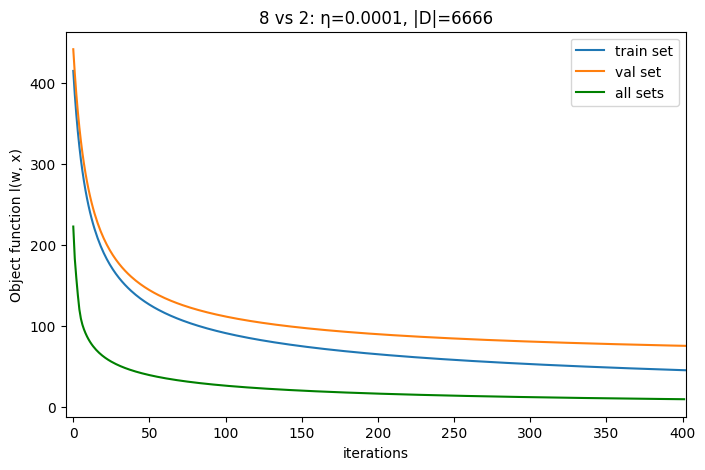

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='train set')
plt.plot(val_loss, label='val set')

plt.plot(all_loss, label='all sets', color='green') 
D_size = X_Tran_and_Val.shape[0]
plt.title(f"8 vs 2: η={best_eta}, |D|={D_size}")
plt.xlabel("iterations")
plt.ylabel("Object function l(w, x)")
plt.legend()
plt.xlim(-5, best_T)
plt.show()

In [ ]:
#Error rate fucntion
def error_rate(lam, X, y):
        pred= (LR(lam,X) >= 0.5).astype(int)
        return np.mean(pred != y)


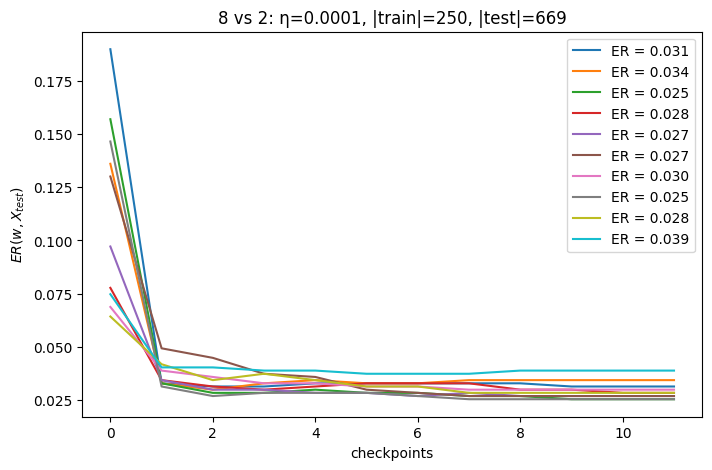

In [ ]:
#This cell consider only two digits 8 and 2..
#Convert 8->1 and 2->0.
#Use batch random or 250 samples from all dataset.
#It run 10 times.
#Plot all differnt error rate. 
#Prepare dataset
X_train_full, Y_train_full = prepate_data(Dtrain_X_norm, Dtrain_Y, eight_digit, two_digit)
X_test, Y_test = prepate_data(Dtest_T_norm, Dtest_T_Y, eight_digit, two_digit)
best_eta, best_T


n_runs = 10
subset_size = 250
all_ER_LR_with_reg = []
for i in range(n_runs):
#create random subset of 250 saamples
    idx = np.random.choice(len(X_train_full), subset_size, replace=False) #ramom index 
    X_subset = X_train_full[idx] 
    Y_subset = Y_train_full[idx]

    lam_final, saved_lams, all_loss = retrain_full_data_GD(X_subset, Y_subset, best_eta, best_T)

    #compute erorr rate 
    ER_ = [error_rate(lam,X_test, Y_test) for lam in saved_lams] 
    all_ER_LR_with_reg.append(ER_)

    #test error rate 
    #print(f'Run {i+1}; Error Rate over iterations: {ER_[-1]:.3f}')


#plot results.
plt.figure(figsize=(8,5))
for ER_curve in all_ER_LR_with_reg:
    plt.plot(range(len(ER_curve)), ER_curve, label=f'ER = {ER_curve[-1]:.3f}')

plt.title(f"8 vs 2: η={best_eta}, |train|={subset_size}, |test|={len(X_test)}")
plt.xlabel("checkpoints")
plt.ylabel(r"$ER(w, X_{test})$")
plt.legend()
plt.show()

In [ ]:
#Euclidin distance function
def euclidian_dist(a, b):
    return np.sqrt(np.sum((a-b)**2))

#computer fuction for K1 
#took form slide
def K1(Dtrain, x):
    N = Dtrain[np.argmin([euclidian_dist(d[0], x) for d in Dtrain])]
    return N[1]

#helper function for KKN
#took form slide
def nearestNeighbours(x,Dtrain, K):
    v = np.argsort([euclidian_dist(d[0], x) for d in Dtrain])
    return [Dtrain[n] for n in v[:K]]

#KNN prefdiction function
#took form the lab
def KNN_pred(x, Dtrian,K, m):
    if K ==1:
        return K1(Dtrian, x)
    else:
        N = nearestNeighbours(x, Dtrian, K)

    #compute probability
        probabilities = [sum([1 for x in N if x[1]==i])/len(N) for i in range(m)]
    return np.argmax(probabilities)    

#compute error rate for KNN
def ER(y_true, y_pred):
    return np.mean(y_true != y_pred)

#evaluate 
def find_best_K(X_train, y_train, X_test,y_test, K_values):
    ##combine X and y for train
    D_train_com = [[X_train[i], y_train[i]] for i in range(len(y_train))]
    #print(f'D_train_com: {len(D_train_com)}')
    errors = []
    for K in K_values:
        y_pred = [KNN_pred(x,D_train_com, K, m=2) for x in X_test]

        err = ER(np.array(y_test), np.array(y_pred))
        errors.append(err)
        ##test print
        #print(f'K={K}, Error Rate={err:.3f}')
        

    
    best_idx = np.argmin(errors)
    best_K = K_values[best_idx]
    best_err = errors[best_idx]
    return best_K, best_err, errors, D_train_com





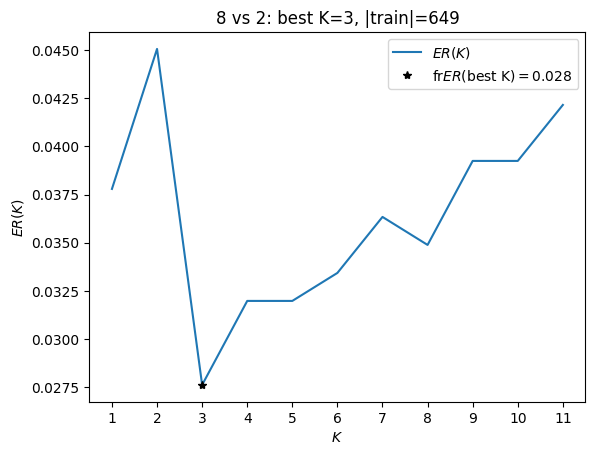

In [ ]:
#This cell call function to find the best K neighbour and plt the result.
K_values = np.arange(1,12)
best_K, best_err, errors, D_train_com = find_best_K(X_Tr,Y_Tr, X_V, Y_V, K_values)

plt.plot(K_values, errors, label=r"$ER(K)$")
plt.plot(best_K, best_err, 'k*', label=fr"fr$ER(\mathrm{{best\;K}})={best_err:.3f}$")
plt.xlabel(r'$K$')
plt.ylabel(r"$ER(K)$")
plt.title(f"8 vs 2: best K={best_K}, |train|={len(D_train_com)}")
plt.legend()

plt.xticks(np.arange(min(K_values), max(K_values+1)))
plt.show()

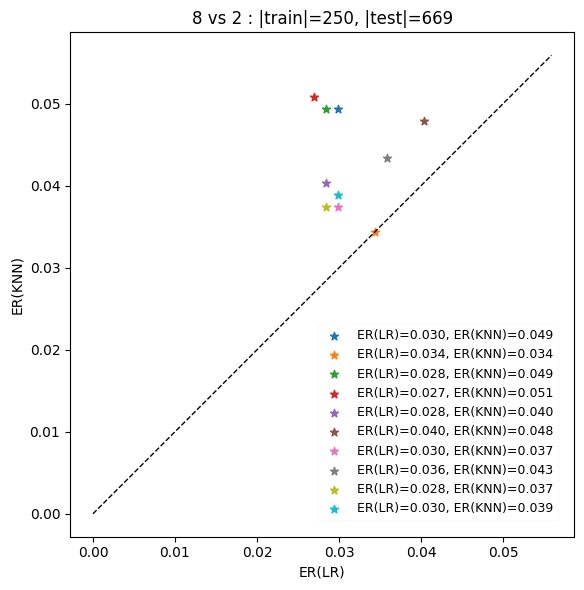

In [ ]:
#This cell convert the data in 1 and 0 for eight and two digit respectively.
#Takes random subset of 250 samples from training set.
#Compute error rate for LR and KNN on same subset.
#plot results.

X_train_full, Y_train_full = prepate_data(Dtrain_X_norm, Dtrain_Y, eight_digit, two_digit)
X_test, Y_test = prepate_data(Dtest_T_norm, Dtest_T_Y, eight_digit, two_digit)
best_eta, best_T



n_runs = 10
subset_size = 250
all_ER_LR_with_reg = []
all_ER_KNN = []
for i in range(n_runs):
#create random subset of 250 saamples
    idx = np.random.choice(len(X_train_full), subset_size, replace=False) #ramom index 
    X_subset = X_train_full[idx] 
    Y_subset = Y_train_full[idx]


    #LR part
    lam_final, saved_lams, all_loss = retrain_full_data_GD(X_subset, Y_subset, best_eta, best_T)

    #compute erorr rate 
    ER_ = [error_rate(lam,X_test, Y_test) for lam in saved_lams] 
    ER_final = ER_[-1]
    all_ER_LR_with_reg.append(ER_final)

    #test error rate 
    #print(f'Run {i+1}; Error Rate over iterations: {ER_[-1]:.3f}')



    #KNN part
    D_train_com = [[X_subset[i], Y_subset[i]] for i in range(len(Y_subset))]
    y_pred = [KNN_pred(x,D_train_com, best_K, m=2) for x in X_test]
    err_KNN = ER(np.array(Y_test), np.array(y_pred))
    all_ER_KNN.append(err_KNN)
    #test print
    #print(f'ER(LR)={ER_final:.3f}, ER(KNN)={err_KNN:.3f}')



plt.figure(figsize=(6,6))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_ER_LR_with_reg))) #colors for points

for i in range(len(all_ER_LR_with_reg)):
    plt.scatter(all_ER_LR_with_reg[i], all_ER_KNN[i],    
                color=colors[i],            #give to color ot the star
                marker='*',
                label=f"ER(LR)={all_ER_LR_with_reg[i]:.3f}, ER(KNN)={all_ER_KNN[i]:.3f}")
    
max_val = max(max(all_ER_LR_with_reg), max(all_ER_KNN))     #gibve size to plot 
padding = 0.1 * max_val                     #add some extra pathing to guarantee all point are in the plot 
lims = [0, max_val + padding]               #size axes
plt.plot(lims, lims, 'k--', linewidth=1)    #diagonal line   

# Make axes square and equal
plt.xlim(lims)
plt.ylim(lims)
# force ve square 
plt.axis('square') 

# Labels and title
plt.xlabel("ER(LR)")        
plt.ylabel("ER(KNN)")
plt.title(f"8 vs 2 : |train|={subset_size}, |test|={len(X_test)}")

# force legend to be in 
plt.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02),                
            frameon=True, facecolor='white', edgecolor='black', fontsize=9,framealpha=0.02)

plt.tight_layout()
plt.show()


In [ ]:
#Function to select continuous, single and upper-bound digits.
def select_digits(X, y, rule, i):
        #print(f'Selecting digits function with rule="{rule}" and i={i}')
        #numbers in G1 are 1 .
        #nuber in G2 are 0.
        if rule == 'contiguous':
            G1 ={i%10, (i+1)%10}
            G2 ={(i+2)%10,(i+3)%10}
            mask_ = np.isin(y, list(G1|G2))
            X_ = X[mask_]
            y_ = y[mask_]
            y_ = (y[mask_] == G1).astype(int)
            y_binary = np.array([1 if label in G1 else 0 for label in y[mask_]])

        #G1 only number i is set to 1.
        #G2 rest to 0.     
        elif rule == 'single':
            G1={i}
            G2= set(range(10)) - G1 
            mask_1 = np.isin(y, list(G1|G2))
            X_ = X[mask_1]
            y_ = y[mask_1]
            y_binary = np.array([1 if label in G1 else 0 for label in y[mask_1]])

        #G1 all number less i are set to 1.
        # G2 all number greather or equal to i are set to 0.        
        elif rule == 'upper':
             G1 = {j for j in range(10) if j< i}
             G2 = {j for j in range(10) if j >= i}
             mask_2 = np.isin(y , list(G1|G2))
             X_ = X[mask_2]
             y_ = y[mask_2]
             y_binary = np.array([1 if label in G1 else 0 for label in y[mask_2]])              
        
        #test
        #print('y_binary:', y_binary)
        return X_, y_, y_binary

In [ ]:
#Compute error rate of LR and KNN
def ER_LR_KNN(X_train, Y_train, X_test,Y_test,best_K,best_eta,best_T, r, i):
    #print(f'ER_LR_KNN function with rule="{r}" and digit={i}')
    n_runs = 10
    subset_size = 250      # number of training samples
    all_ER = []
    ER_KNN = []
    for i in range(n_runs):
      #create random subset of 250 saamples
      idx = np.random.choice(len(X_train_full), subset_size, replace=False) #ramom index 
      X_subset = X_train[idx] 
      Y_subset = Y_train[idx]


      #LR part
      #final_lam
      lam_final, saved_lams, all_loss = retrain_full_data_GD(X_subset, Y_subset, best_eta, best_T)

      #compute erorr rate 
      ER_ = [error_rate(lam,X_test, Y_test) for lam in saved_lams] 
      #ER_ = [error_rate(lam,X_test, Y_test) for lam in lam_final]
      ER_final = ER_[-1]
      all_ER.append(ER_final)

      #test error rate 
      #print(f'Run {i+1}; Error Rate over iterations: {ER_[-1]:.3f}')



      #KNN part
      D_train_com = [[X_subset[i], Y_subset[i]] for i in range(len(Y_subset))]
      y_pred = [KNN_pred(x,D_train_com, best_K, m=2) for x in X_test]
      err_KNN = ER(np.array(Y_test), np.array(y_pred))
      ER_KNN.append(err_KNN)

      #test print
      #print(f'ER(LR)={ER_final:.3f}, ER(KNN)={err_KNN:.3f}')
        
    return all_ER, ER_KNN
        

In [ ]:
#Plot error rate of LR and KNN
def plot_ER_LR_KNN(all_ER, ER_KNN,r,dgt):
    #test
    #print(f'plot_ER_LR_KNN rule: {r}, digit: {dgt}')

    plt.figure(figsize=(6,6))

    colors = plt.cm.tab10(np.linspace(0, 1, len(all_ER))) #colors for points

    for i in range(len(all_ER)):
        plt.scatter(all_ER[i], ER_KNN[i],    
                    color=colors[i],            #give to color ot the star
                    marker='*',
                    label=f"ER(LR)={all_ER[i]:.3f}, ER(KNN)={ER_KNN[i]:.3f}")
        
    max_val = max(max(all_ER), max(ER_KNN))     #gibve size to plot 
    padding = 0.1 * max_val                     #add some extra pathing to guarantee all point are in the plot 
    lims = [0, max_val + padding]               #size axes
    plt.plot(lims, lims, 'k--', linewidth=1)    #diagonal line   

    # Make axes square and equal
    plt.xlim(lims)
    plt.ylim(lims)
    plt.axis('square')           # force ve square 

    # Labels and title
    plt.xlabel("ER(LR)")        
    plt.ylabel("ER(KNN)")
    #plt.title(f"|train|={subset_size}, |test|={len(X_test)}")

    #helper for the title
    #it diplay thr fidgit selection rule.
    if r == 'contiguous':
        G1 = [dgt % 10, (dgt + 1) % 10]
        G2 = [(dgt + 2) % 10, (dgt + 3) % 10]
        title_text = f"digits: {G1} vs {G2}"
    elif r == 'single':
        G1 = [dgt]
        G2 = [j for j in range(10) if j != dgt]
        title_text = f"digit {G1} vs all others"
    elif r == 'upper':
        G1 = [j for j in range(10) if j < dgt]
        G2 = [j for j in range(10) if j >= dgt]
        title_text = f"digits: {G1} vs {G2}"

    plt.title(title_text)
    # force legend to be in...
    plt.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02),                
                frameon=True, facecolor='white', edgecolor='black', fontsize=9,framealpha=0.02)

    plt.tight_layout()
    plt.show()


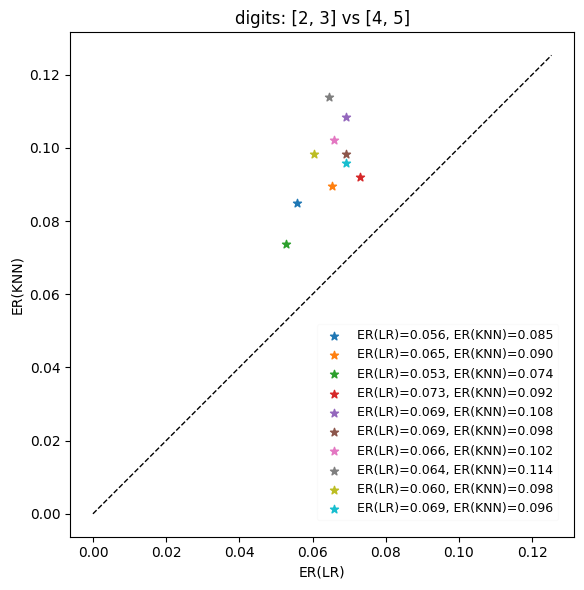

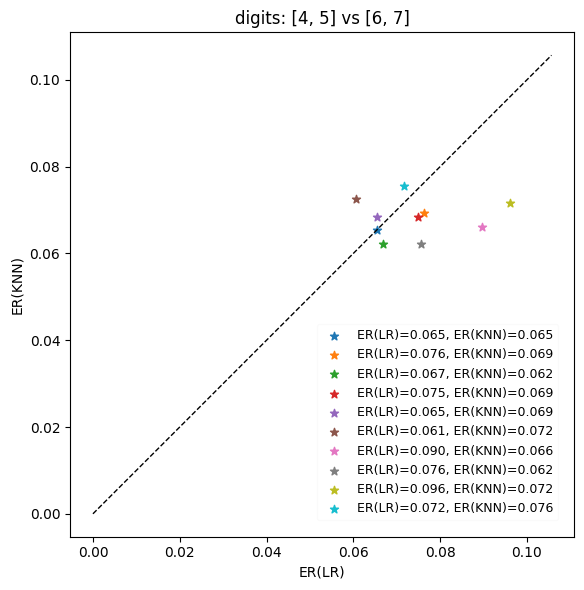

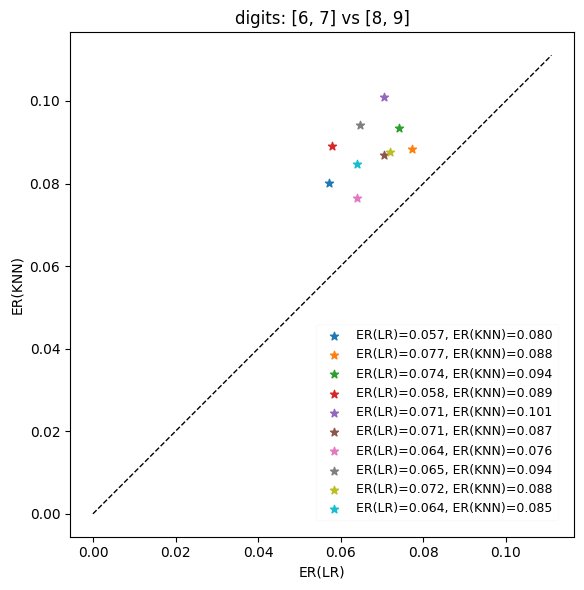

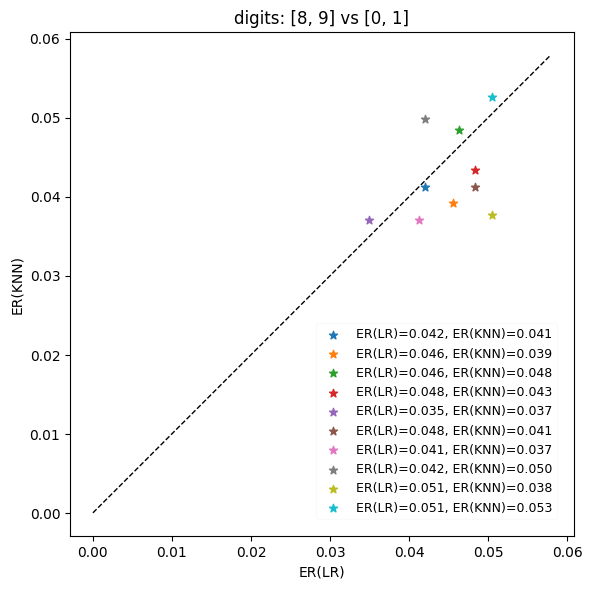

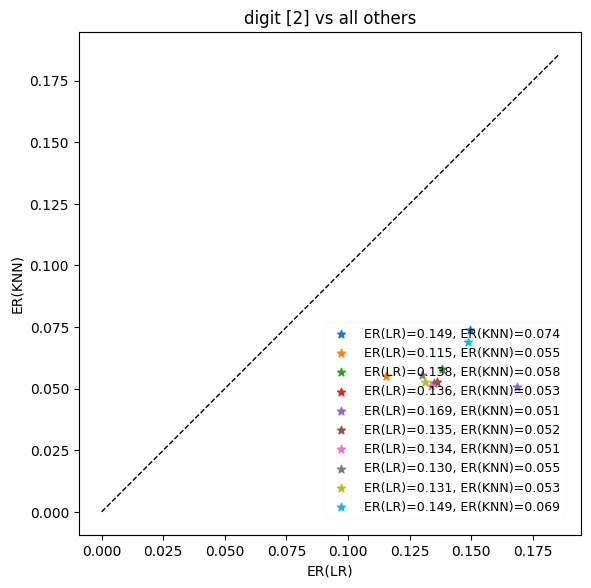

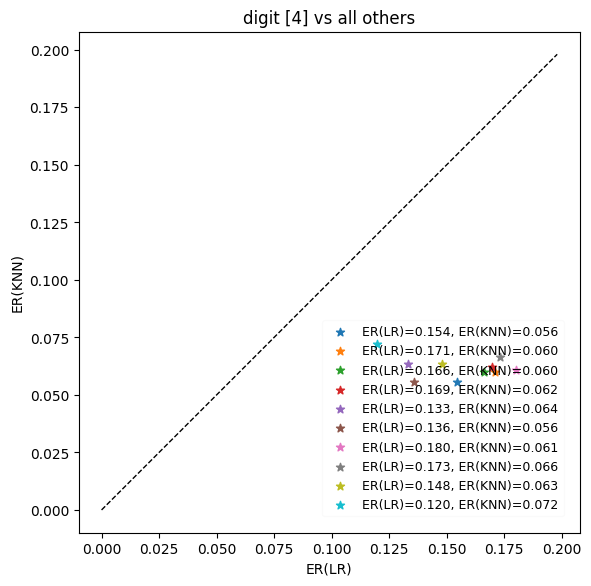

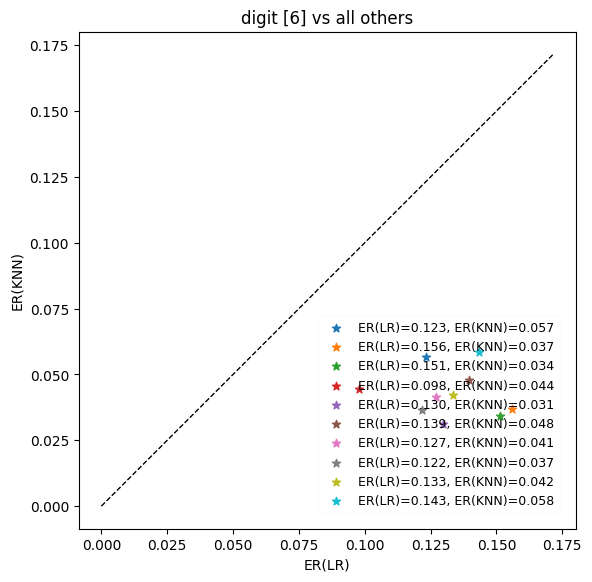

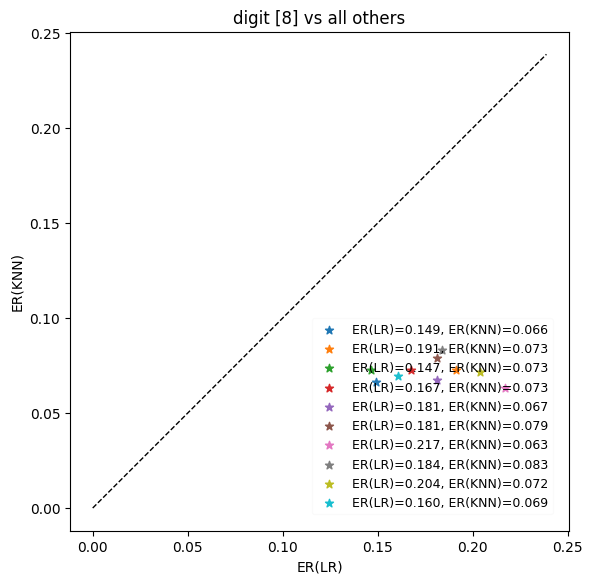

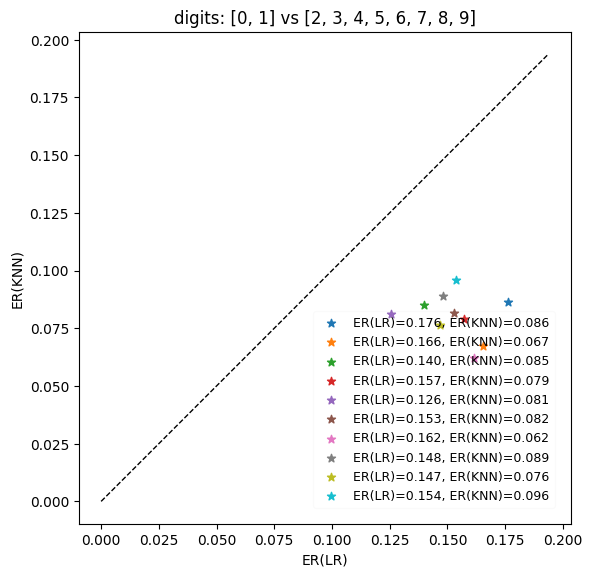

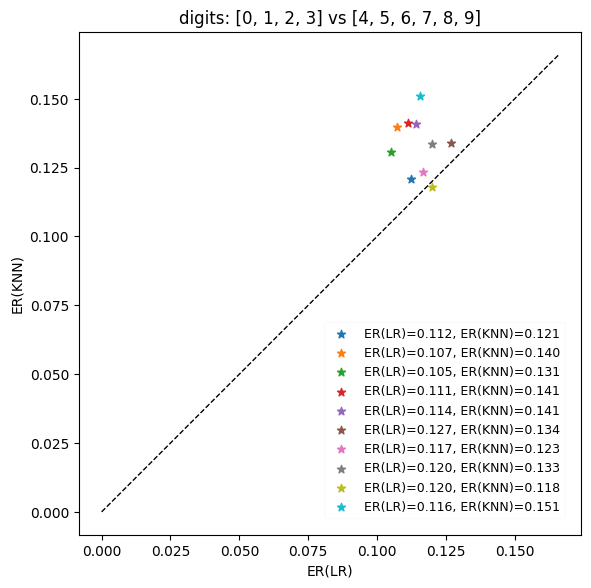

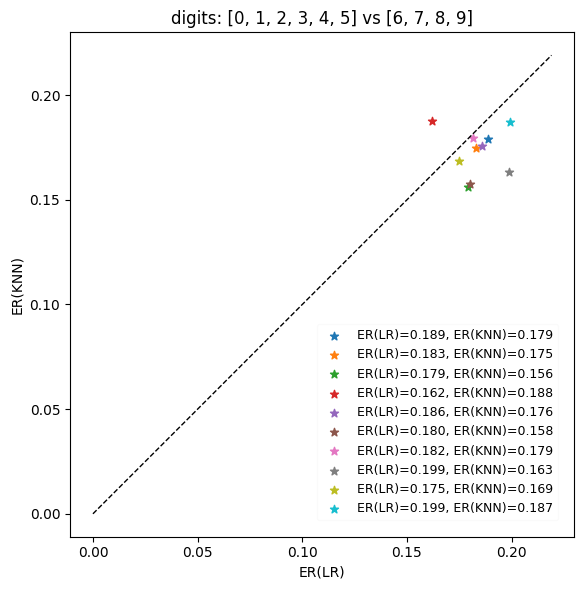

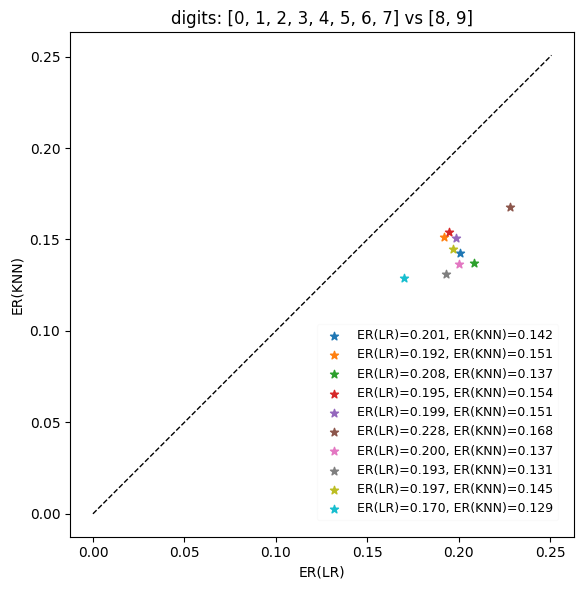

In [ ]:
#It call the funtion repsonsible of to calucalte error rate for LR and KNN. and plot one.
rule = ['contiguous', 'single', 'upper']
digit = [2,4,6,8]
for rule in rule: 
    for i in digit:
        X_train_full, _, Y_train_full = select_digits(Dtrain_X_norm, Dtrain_Y, rule, i)
        X_test, _, Y_test = select_digits(Dtest_T_norm, Dtest_T_Y, rule, i)
        best_eta, best_T, best_K
        all_ER_LR_with_reg, all_ER_KNN = ER_LR_KNN(X_train_full, Y_train_full, X_test,Y_test,best_K,best_eta,best_T, rule, i)
        plot_ER_LR_KNN(all_ER_LR_with_reg, all_ER_KNN, rule, i)

In [ ]:
#all objective functions and cost functions with and without regularization.
# Negative log-likelihood with L2 regularization.
def neg_log_lokelihood_With_Reg(lam, X, y, alpha, eps=1e-8):
    f = LR(lam, X)
    loss = - np.sum(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))
    #lam[:1] to avoid regualarizion to bias
    loss += (alpha / 2) * np.sum(lam[1:] ** 2) #L2 regularization term
    return loss

# Gradient of the loss with L1 regul
def grad_neg_log_likelihood_With_Reg(lam, X, y, alpha):
    f = LR(lam, X)
    X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    grad = X_bias.T @ (f - y)
    grad[1:] += alpha * lam[1:]  #L2 regularizatio
    return grad

# Training loop with gradient descent
def train_logistic_GD_Wtih_Reg(X_train, y_train, X_val, y_val, eta, T, alpha):
    d = X_train.shape[1]
    lam = np.zeros(d + 1)
    
    train_loss, val_loss = [], []

    for t in range(T):
        grad = grad_neg_log_likelihood_With_Reg(lam, X_train, y_train, alpha)
        lam -= eta * grad

        train_loss.append(neg_log_lokelihood_With_Reg(lam, X_train, y_train, alpha))
        val_loss.append(neg_log_lokelihood_With_Reg(lam, X_val, y_val, alpha))
    
    return lam, train_loss, val_loss


In [ ]:
#This cell consider only 8 and 2 digit.
#Tranfsorm 8->1 and 2->0.
#Find best alpha.

#prepare data for 8 and 2
eight_digit, two_digit = 8, 2
X_Tr, Y_Tr = prepate_data(Dtrain_X_norm, Dtrain_Y, eight_digit, two_digit)
#test
#print('X_Tr shape:', X_Tr.shape)
#print('Y_Tr shape:', Y_Tr.shape)
X_V, Y_V = prepate_data(Dval_V_norm, Dval_V_Y, eight_digit, two_digit)
#test
#print('X_V shape:', X_V.shape)



alphas = [10**i for i in range(-8,3)] #crate list obetween 1e-8 to 1e2
eta= 0.001
T = 500
val_errors = []
for alpha in alphas:
     # Train model
    lam, train_loss, val_loss = train_logistic_GD_Wtih_Reg(X_Tr, Y_Tr, X_V, Y_V, eta, T, alpha)
    
    err_rate = error_rate(lam, X_V, Y_V)
    val_errors.append(err_rate)
    
    print(f"Alpha={alpha:.1e}, Train loss={train_loss[-1]:.3f}, "
           f"Val loss={val_loss[-1]:.3f}, Val ER={err_rate:.3f}")
    #print(f'Alpha={alpha}, Validation Error Rate={err_rate:.3f}')




Alpha=1.0e-08, Train loss=0.527, Val loss=130.614, Val ER=0.042
Alpha=1.0e-07, Train loss=0.527, Val loss=130.614, Val ER=0.042
Alpha=1.0e-06, Train loss=0.527, Val loss=130.614, Val ER=0.042
Alpha=1.0e-05, Train loss=0.527, Val loss=130.613, Val ER=0.042
Alpha=1.0e-04, Train loss=0.528, Val loss=130.611, Val ER=0.042
Alpha=1.0e-03, Train loss=0.538, Val loss=130.581, Val ER=0.042
Alpha=1.0e-02, Train loss=0.641, Val loss=130.286, Val ER=0.041
Alpha=1.0e-01, Train loss=1.591, Val loss=127.324, Val ER=0.041
Alpha=1.0e+00, Train loss=6.791, Val loss=96.793, Val ER=0.036
Alpha=1.0e+01, Train loss=24.463, Val loss=71.884, Val ER=0.033
Alpha=1.0e+02, Train loss=3867.011, Val loss=3631.226, Val ER=0.328


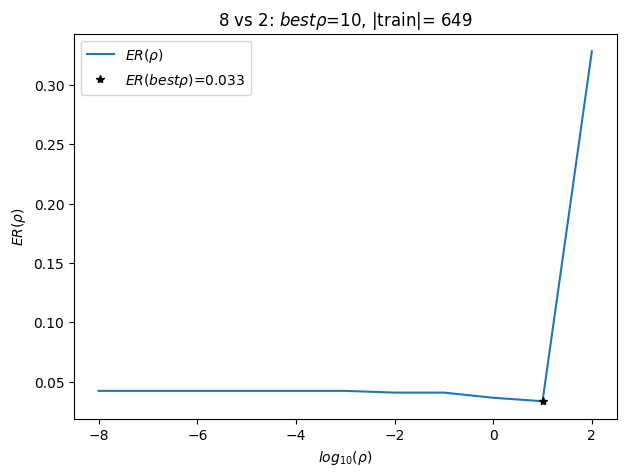

In [39]:
best_idx = np.argmin(val_errors)
alpha = alphas[best_idx]
best_error = val_errors[best_idx]

def plot_LR_with_Regulatization(alphas, val_errors, best_alpha, best_error):
    plt.figure(figsize=(7,5))
    plt.plot(np.log10(alphas), val_errors, label= "$ER(\\rho)$")
    plt.plot(np.log10(best_alpha), best_error,'k*', label=f'$ER(best \\rho)$={best_error:.3f}')
    plt.title(f'8 vs 2: $best\\rho$={best_alpha}, |train|= {len(X_Tr)}')
    plt.xlabel('$log_{10}(\\rho)$')
    plt.ylabel('$ER(\\rho)$')
    plt.legend()
    plt.show()
    
plot_LR_with_Regulatization(alphas, val_errors, alpha, best_error)

In [ ]:
#Code reused from previous form above
#Function to select continuous, single and upper-bound digits.
def select_digits(X, y, rule, i):
        #print(f'Selecting digits function with rule="{rule}" and i={i}')
        #numbers in G1 are 1 .
        #nuber in G2 are 0.
        if rule == 'contiguous':
            G1 ={i%10, (i+1)%10}
            G2 ={(i+2)%10,(i+3)%10}
            mask_ = np.isin(y, list(G1|G2))
            X_ = X[mask_]
            y_ = y[mask_]
            y_ = (y[mask_] == G1).astype(int)
            y_binary = np.array([1 if label in G1 else 0 for label in y[mask_]])

        #G1 is 1 
        #rest are 0.    
        elif rule == 'single':
            G1={i}
            G2= set(range(10)) - G1 
            mask_1 = np.isin(y, list(G1|G2))
            X_ = X[mask_1]
            y_ = y[mask_1]
            y_binary = np.array([1 if label in G1 else 0 for label in y[mask_1]])

        #all number less than i are 1 and all greater or equeal are 0.
        elif rule == 'upper':
             G1 = {j for j in range(10) if j< i}
             G2 = {j for j in range(10) if j >= i}
             mask_2 = np.isin(y , list(G1|G2))
             X_ = X[mask_2]
             y_ = y[mask_2]
             y_binary = np.array([1 if label in G1 else 0 for label in y[mask_2]])              
            
        #print('y_binary:', y_binary)
        return X_, y_, y_binary

In [ ]:
# Objective function and cost function with and without regularization.
# Negative log-likelihood with L2 regularization.
def neg_log_lokelihood_With_Reg(lam, X, y, alpha, eps=1e-8):
    #print(f'Computing loss with alpha={alpha}')
    f = LR(lam, X)
    loss = - np.sum(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))
    #lam[:1] to avoid regualarizion to bias
    #loss += (alpha / 2) * np.sum(np.abs(lam[1:]))
    loss += (alpha / 2) * np.sum(lam[1:] ** 2) #L2 regularization  
    return loss

# Gradient of the loss with L2
def grad_neg_log_likelihood_With_Reg(lam, X, y, alpha):
    #print(f'Computing gradient with alpha={alpha}')
    f = LR(lam, X)
    X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    grad = X_bias.T @ (f - y)
    #grad[1:] += alpha * np.sign(lam[1:])  # skip bias regularization
    grad[1:] += alpha * lam[1:]  #L2 regularization
    return grad

# Training loop with gradient descent
def train_logistic_GD_Wtih_Reg(X_train, y_train, X_val, y_val, eta, T, alpha):
    #print(f'Starting training with alpha={alpha}')
    d = X_train.shape[1]
    lam = np.zeros(d + 1)
    
    train_loss, val_loss = [], []

    for t in range(T):
        grad = grad_neg_log_likelihood_With_Reg(lam, X_train, y_train, alpha)
        lam -= eta * grad

        train_loss.append(neg_log_lokelihood_With_Reg(lam, X_train, y_train, alpha))
        val_loss.append(neg_log_lokelihood_With_Reg(lam, X_val, y_val, alpha))
    
    return lam, train_loss, val_loss




#negative likehood with not regularization
def neg_log_lokelihood_NO_Reg(lam, X, y, eps=1e-8):
    f = LR(lam, X)
    loss = - np.sum(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))
    return loss

# Gradient of the loss with not regolarization 
def grad_neg_log_likelihood_NO_Reg(lam, X, y):
    f = LR(lam, X)
    X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    grad = X_bias.T @ (f - y)
    return grad

# Training loop with gradient descent not regularization 
def train_logistic_GD_NO_Reg(X_train, y_train, X_val, y_val, eta, T):
    d = X_train.shape[1]
    lam = np.zeros(d + 1)
    
    train_loss, val_loss = [], []

    #this loop update poarameters
    for t in range(T):
        grad = grad_neg_log_likelihood_NO_Reg(lam, X_train, y_train)
        lam -= eta * grad

        train_loss.append(neg_log_lokelihood_NO_Reg(lam, X_train, y_train))
        val_loss.append(neg_log_lokelihood_NO_Reg(lam, X_val, y_val))
    
    return lam, train_loss, val_loss

In [ ]:
#This fucntion return the error rates of the LR(with regualrization) LR no regualrization and KNN.
#it takes batch of 250 samples and compute loss.
def ER_LR_LR_with_reg_KNN(X_train, Y_train, X_test,Y_test,best_K,best_eta, T, rule, digit, alpha):
    #print(f'ER_LR_KNN function with rule="{rule}" and digit={digit}')
    n_runs = 10
    subset_size = 250      # number of training samples
    all_ER_LR = []
    all_ER_KNN = []
    all_ER_LR_with_reg = []
    for run in range(n_runs):
      #create random subset of 250 saamples
      idx = np.random.choice(len(X_train_full), subset_size, replace=False) #ramom index 
      X_subset = X_train[idx] 
      Y_subset = Y_train[idx]


       #LR part Unregularized
      lam, _, _ = train_logistic_GD_NO_Reg(X_subset, Y_subset, X_test, Y_test, best_eta, T)
       #compute erorr rate 
      err_rate_LR = error_rate(lam, X_test, Y_test)
      all_ER_LR.append(err_rate_LR)

     #LR part qith L2 regularization
      lam_reg, _, _ = train_logistic_GD_Wtih_Reg(X_subset, Y_subset, X_test, Y_test, best_eta, T, alpha)
      #compute erorr rate 
      err_rate_LR_reg= error_rate(lam_reg, X_test, Y_test)
      all_ER_LR_with_reg.append(err_rate_LR_reg)


      #KNN part
      D_train_com = [[X_subset[i], Y_subset[i]] for i in range(len(Y_subset))]
      y_pred = [KNN_pred(x,D_train_com, best_K, m=2) for x in X_test]
      err_KNN = ER(np.array(Y_test), np.array(y_pred))
      all_ER_KNN.append(err_KNN)

      #test
      #print(f'Alpha={alpha} ER(LR)={err_rate_LR:.3f}, ER(LR_with_reg)={err_rate_LR_reg:.3f} ER(KNN)={err_KNN:.3f}')
        
    return all_ER_LR,all_ER_LR_with_reg ,all_ER_KNN
        

In [ ]:
#This function plot KNN and LR(with not regularization).
#I kept the function separate to avoid code issues.
#Mostly of other code used it takes from the previous function.
def plot_ER_LR_KNN(all_ER, ER_KNN,r,dgt):
    #print(f'plot_ER_LR_KNN rule: {r}, digit: {dgt}')

    plt.figure(figsize=(6,6))

    colors = plt.cm.tab10(np.linspace(0, 1, len(all_ER))) #colors for points

    for i in range(len(all_ER)):
        plt.scatter(all_ER[i], ER_KNN[i],    
                    color=colors[i],            #give to color ot the star
                    marker='*',
                    label=f"ER(LR)={all_ER[i]:.3f}, ER(KNN)={ER_KNN[i]:.3f}")
        
    max_val = max(max(all_ER), max(ER_KNN))     #gibve size to plot 
    padding = 0.1 * max_val                     #add some extra pathing to guarantee all point are in the plot 
    lims = [0, max_val + padding]               #size axes
    plt.plot(lims, lims, 'k--', linewidth=1)    #diagonal line   

    
    # Make axes square and equal
    plt.xlim(lims)
    plt.ylim(lims)
    #helper for diagonal
    plt.axis('square')           

    # Labels and title
    plt.xlabel("ER(LR)")        
    plt.ylabel("ER(KNN)")
    #plt.title(f"|train|={subset_size}, |test|={len(X_test)}")

    #helper statement to diplay the diffent rules. 
    if r == 'contiguous':
        G1 = [dgt % 10, (dgt + 1) % 10]
        G2 = [(dgt + 2) % 10, (dgt + 3) % 10]
        title_text = f"digits: {G1} vs {G2}"
    elif r == 'single':
        G1 = [dgt]
        G2 = [j for j in range(10) if j != dgt]
        title_text = f"digit {G1} vs all others"
    elif r == 'upper':
        G1 = [j for j in range(10) if j < dgt]
        G2 = [j for j in range(10) if j >= dgt]
        title_text = f"digits: {G1} vs {G2}"

    plt.title(title_text)
    # force legend to be in 
    plt.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02),                
                frameon=True, facecolor='white', edgecolor='black', fontsize=9, framealpha=0.02)

    plt.tight_layout()
    plt.show()


In [ ]:
#Plot KNN and LR(with regularization).
#I kept the fucntion separate  to avoid code issues.
#Mostly of code used is from the previous function.
def plot_ER_LR_REG_KNN(all_ER_LR_with_reg, all_ER_KNN,rule,digit,alpha): 
    #print(f'plot_ER_LR_KNN rule: {rule}, digit: {digit}')

    plt.figure(figsize=(6,6))

    colors = plt.cm.tab10(np.linspace(0, 1, len(all_ER_LR_with_reg))) #colors for points

    for i in range(len(all_ER_LR_with_reg)):
        
        plt.scatter(all_ER_KNN[i],all_ER_LR_with_reg[i],    
                    color=colors[i],            #give to color ot the star
                    marker='*',
                  
                    label=f"ER($\\rho={alpha}$)={all_ER_LR_with_reg[i]:.3f}, ER(KNN)={all_ER_KNN[i]:.3f}")
                   
        
    max_val = max(max(all_ER_LR_with_reg), max(all_ER_KNN))     #give size to plot 
    padding = 0.1 * max_val                     #add some extra pathing to guarantee all point are in the plot 
    lims = [0, max_val + padding]               #size axes
    plt.plot(lims, lims, 'k--', linewidth=1)    #diagonal line   

    # Make axes square and equal
    plt.xlim(lims)
    plt.ylim(lims)
    plt.axis('square')           # force ve square 

    # Labels and title
    plt.ylabel("ER(LR_WITH_REG)")        
    plt.xlabel("ER(KNN)")
    #plt.title(f"|train|={subset_size}, |test|={len(X_test)}")

    if rule == 'contiguous':
        G1 = [digit % 10, (digit + 1) % 10]
        G2 = [(digit + 2) % 10, (digit + 3) % 10]
        title_text = f"digits: {G1} vs {G2}"
    elif rule == 'single':
        G1 = [digit]
        G2 = [j for j in range(10) if j != digit]
        title_text = f"digit {G1} vs all others"
    elif rule == 'upper':
        G1 = [j for j in range(10) if j < digit]
        G2 = [j for j in range(10) if j >= digit]
        title_text = f"digits: {G1} vs {G2}"

    plt.title(title_text)
    # force legend to be fix splot.
    plt.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02),                 
                frameon=True, facecolor='white', edgecolor='black', fontsize=9, framealpha=0.02)
    

    plt.tight_layout()
    plt.show()


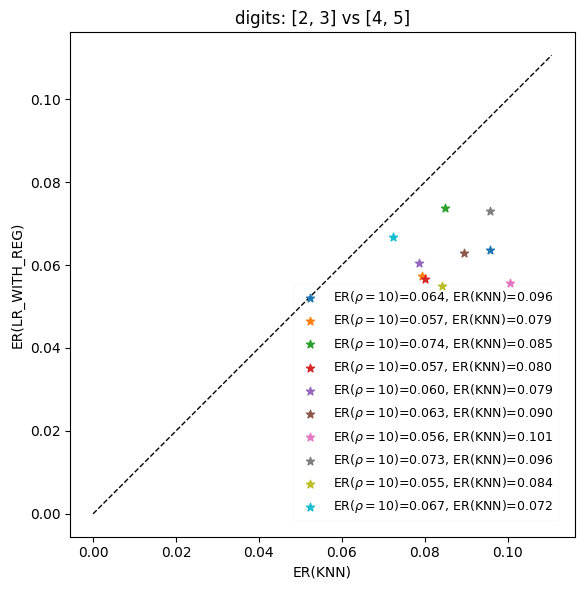

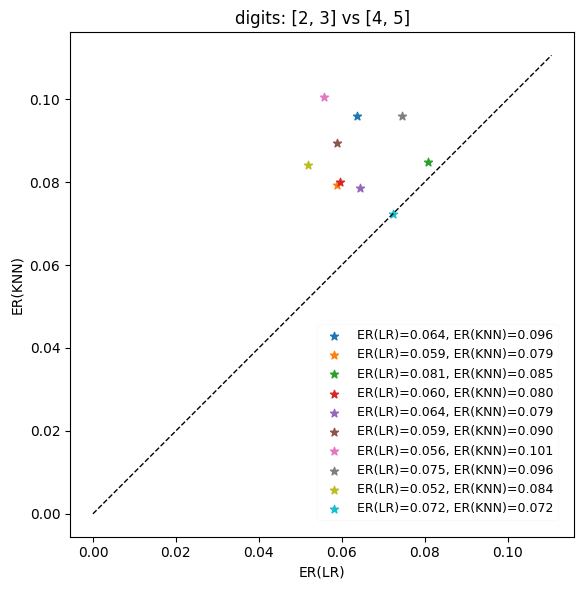

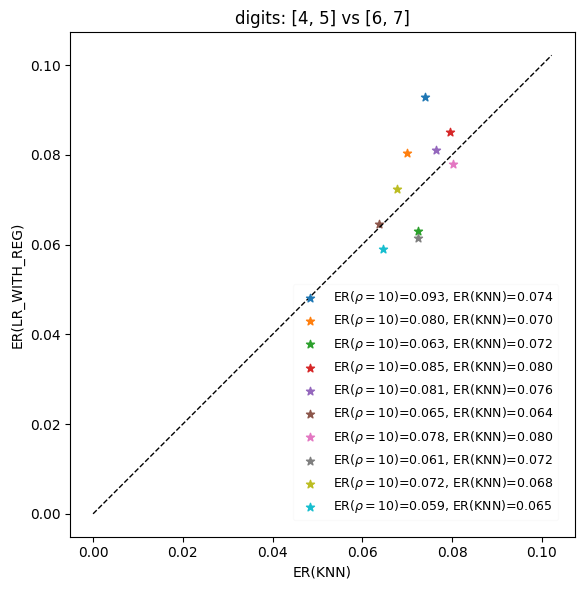

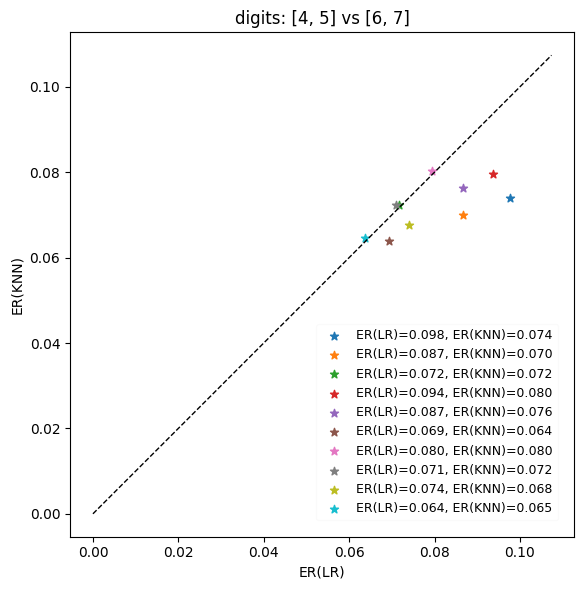

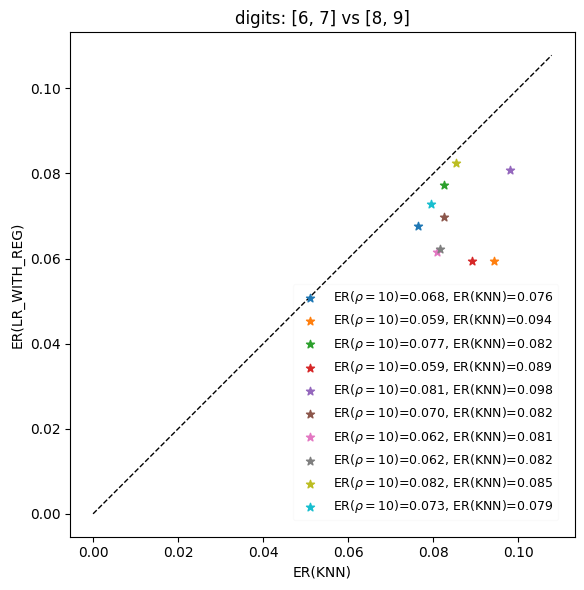

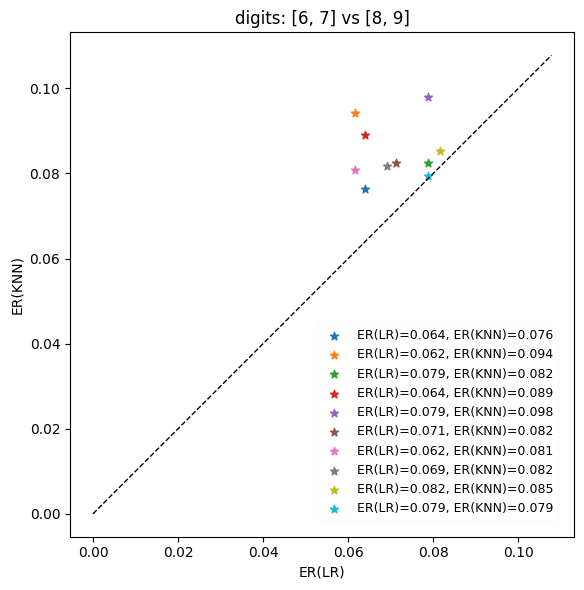

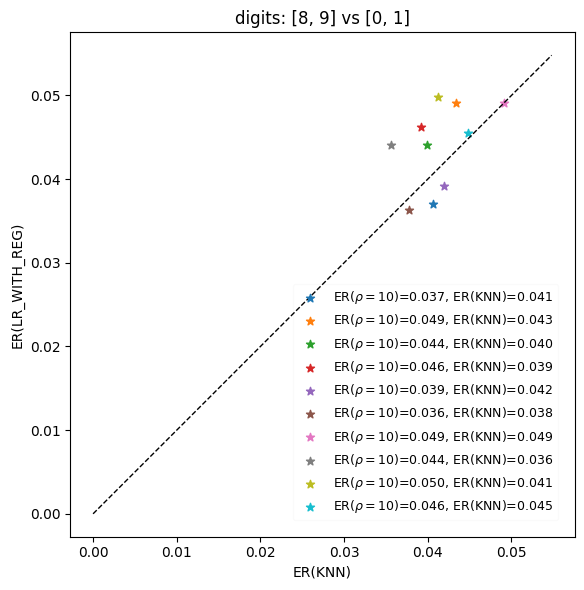

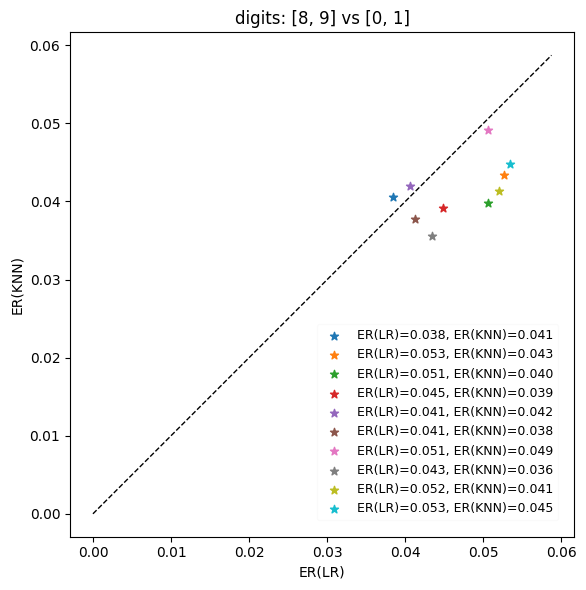

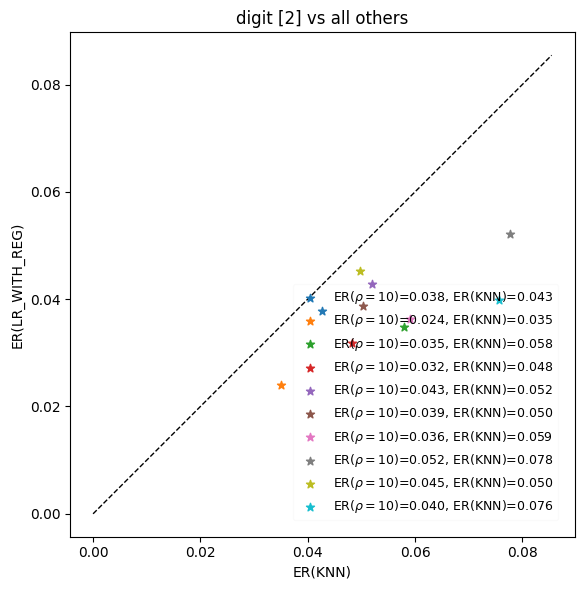

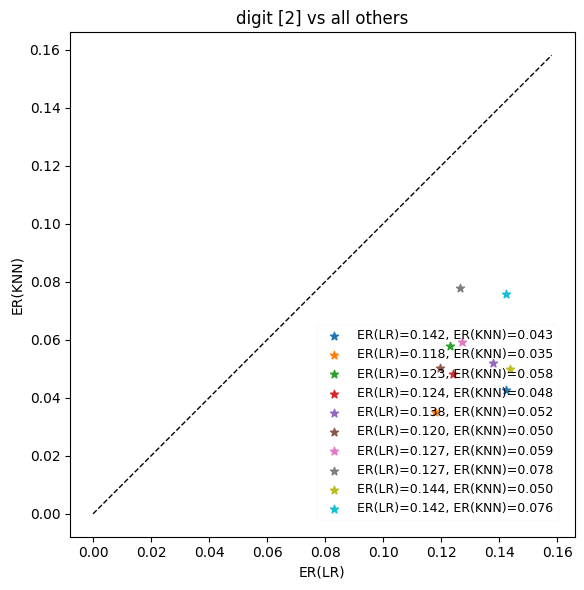

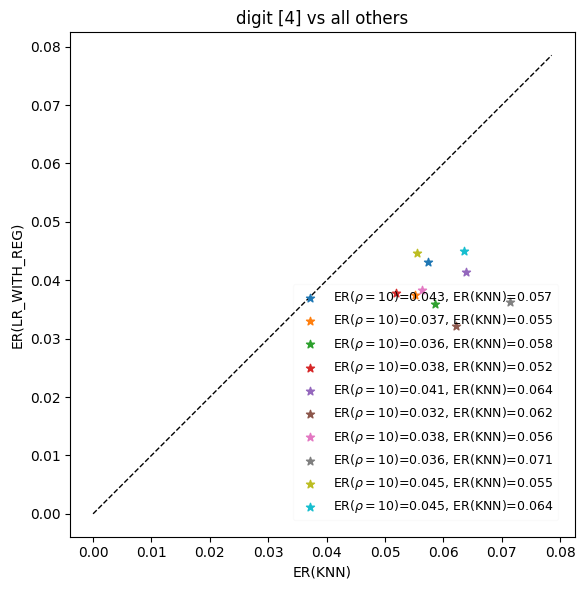

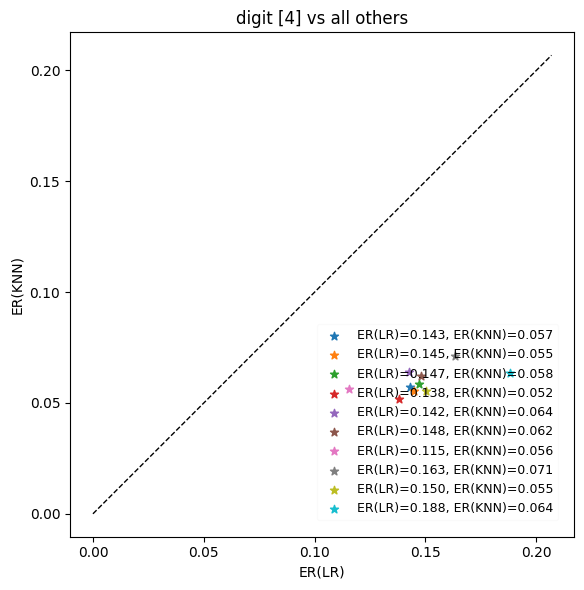

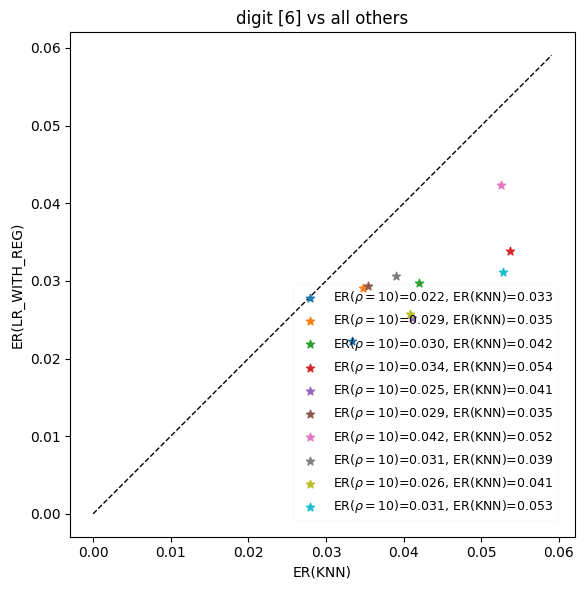

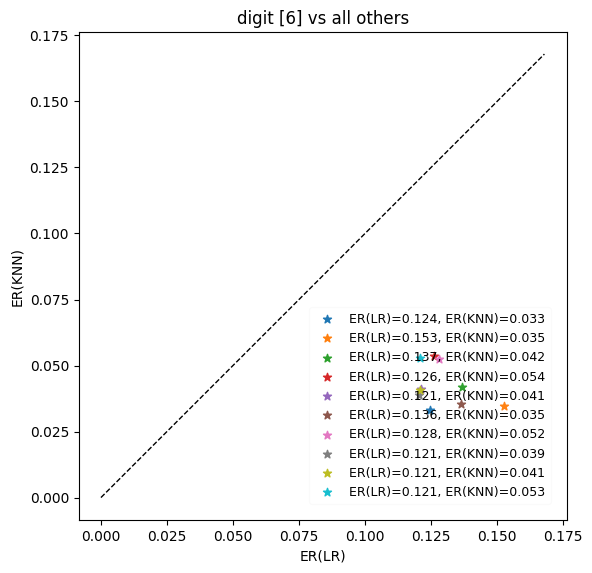

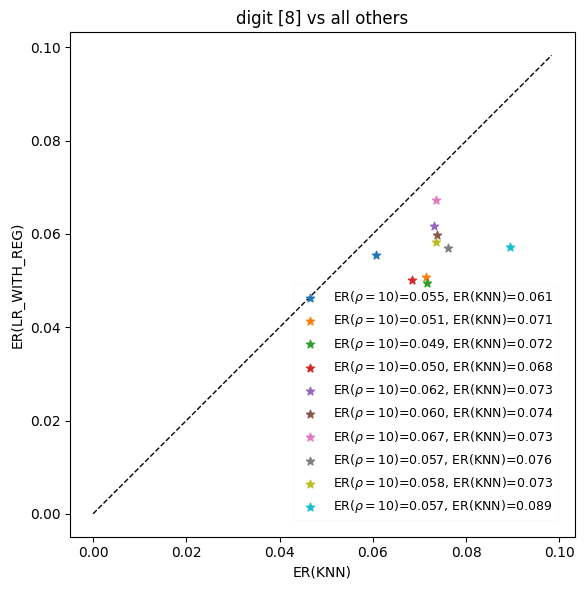

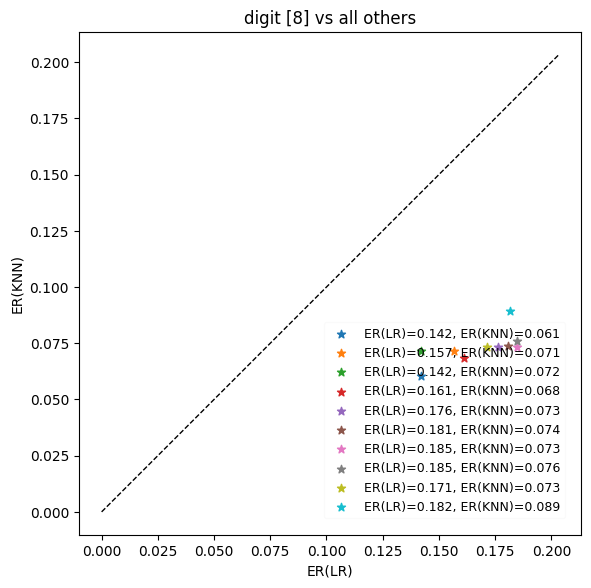

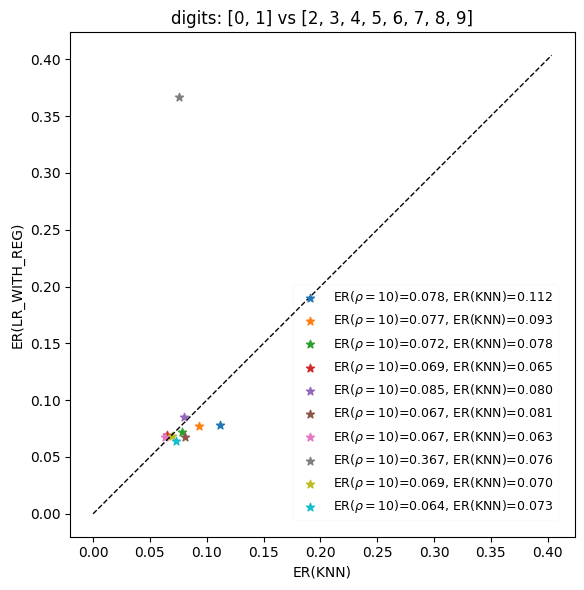

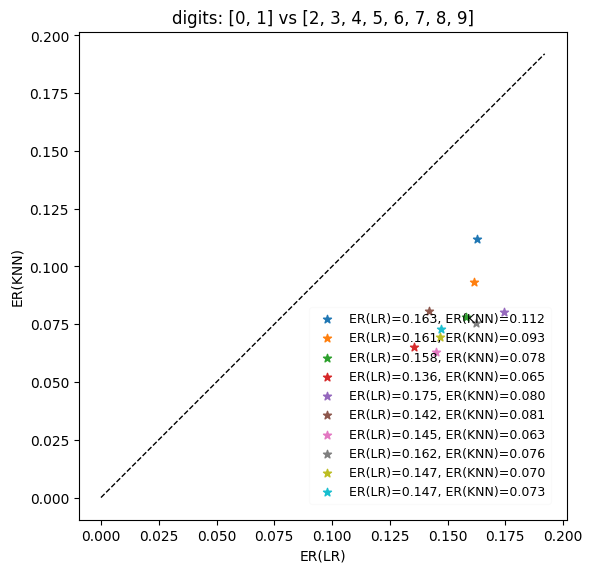

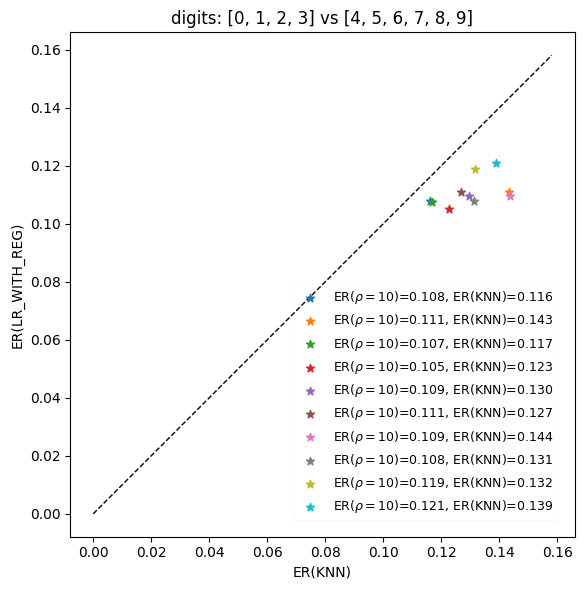

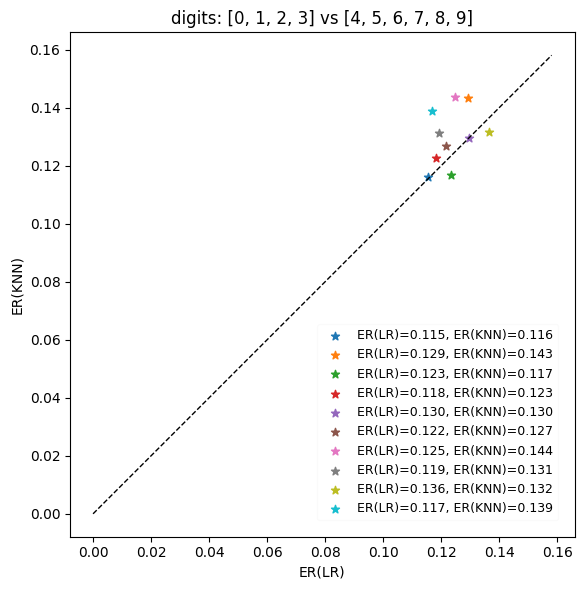

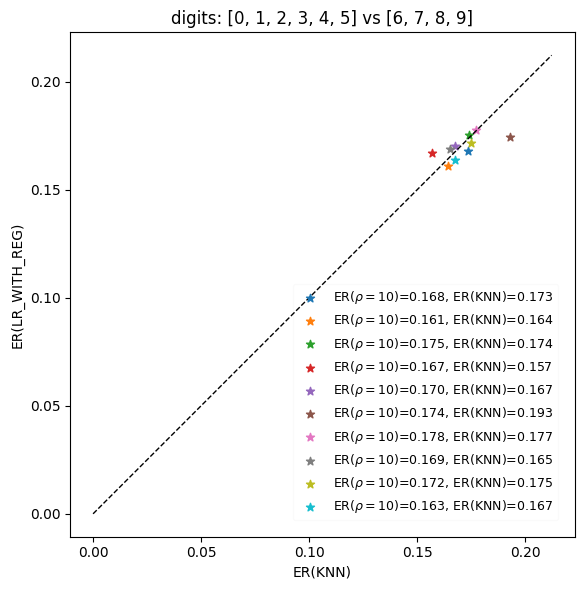

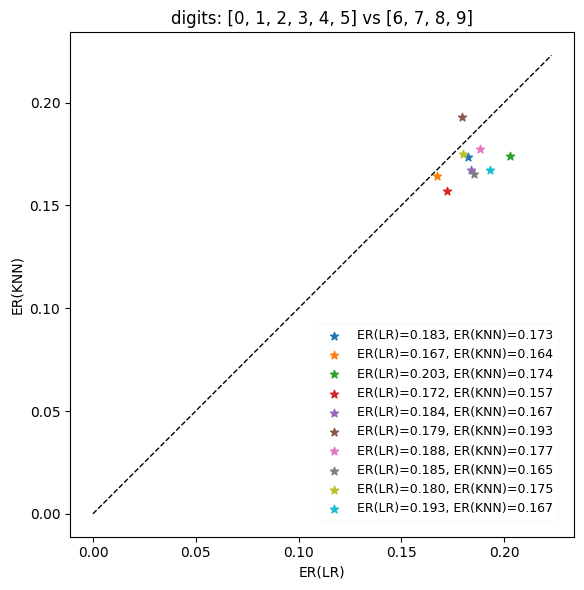

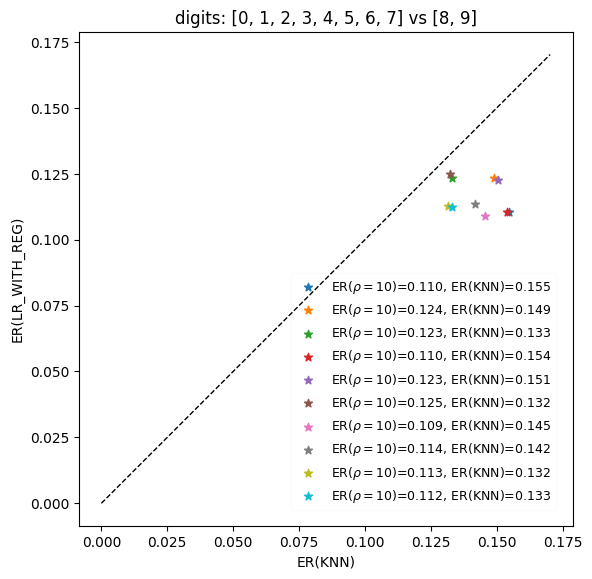

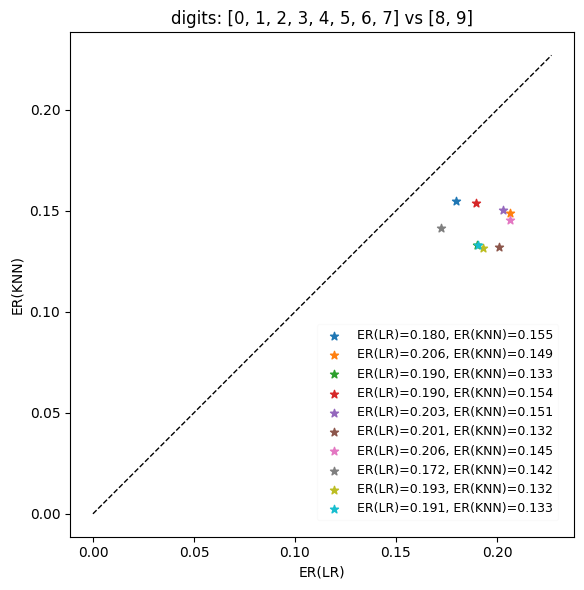

In [45]:
#In this task, I compared the KNN LR(with regualrization) and LR no regualrization.
#The models used The best Hyperparameters that I found in the previous sections.
#I have list of digits in [2,4,6,8]
eta= 0.001 #best eta fount aabove
T = 500
best_K #best K for KNN
rules = ['contiguous', 'single', 'upper']
digits = [2,4,6,8] 
alpha = 10 #best alpha 
for rule in rules: 
    for digit in digits:
        X_train_full, _, Y_train_full = select_digits(Dtrain_X_norm, Dtrain_Y, rule, digit)
        X_test, _, Y_test = select_digits(Dtest_T_norm, Dtest_T_Y, rule, digit)
        #print(best_K)
        all_ER_LR,all_ER_LR_with_reg ,all_ER_KNN = ER_LR_LR_with_reg_KNN(X_train_full, Y_train_full, X_test,Y_test,best_K,eta, T, rule, digit, alpha)
        #two plots.
        #one for LR with regualrization and KNN.
        #one for LR no regualrization and KNN.
        for er in range(1,3):
            if er == 1:
                #print('er ',er)
                plot_ER_LR_REG_KNN(all_ER_LR_with_reg, all_ER_KNN, rule, digit,alpha)
            else:
                #print('er ',er)
                plot_ER_LR_KNN(all_ER_LR, all_ER_KNN, rule, digit)
